In [ ]:
!nvidia-smi

Fri May  8 07:01:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install cupy-cuda12x

CuPy GPU FFT Time: 1.412267 seconds


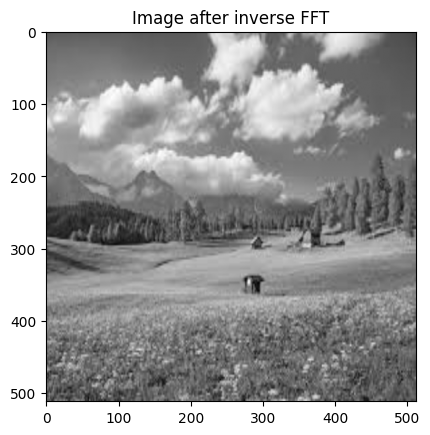

In [ ]:
import cupy as cp
import cv2
from time import time
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('landscape.jpeg', 0)

if img is None:
    print("Image not found!")
    exit()

# Resize image
img = cv2.resize(img, (512, 512))

# Transfer image to GPU
gpu_img = cp.asarray(img)

# GPU FFT timing
start = time()

gpu_fft = cp.fft.fft2(gpu_img)

# Wait for GPU completion
cp.cuda.Stream.null.synchronize()

end = time()

print(f"CuPy GPU FFT Time: {end-start:.6f} seconds")

# Inverse FFT
img_back = cp.fft.ifft2(gpu_fft)

# Transfer back to CPU
img_back = cp.asnumpy(img_back.real)

# Display image
plt.imshow(img_back, cmap='gray')
plt.title("Image after inverse FFT")
plt.show()

In [ ]:
import cupy as cp
import cv2
from time import time

img = cv2.imread('landscape.jpeg', 0)
img = cv2.resize(img, (512,512))

gpu_img = cp.asarray(img)

# Warmup run
cp.fft.fft2(gpu_img)
cp.cuda.Stream.null.synchronize()

# Actual timing
start = time()

gpu_fft = cp.fft.fft2(gpu_img)

cp.cuda.Stream.null.synchronize()

end = time()

print(f"Actual CuPy GPU FFT Time: {end-start:.6f} seconds")

Actual CuPy GPU FFT Time: 0.000906 seconds


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Custom GPU FFT Time: 1.917917 seconds


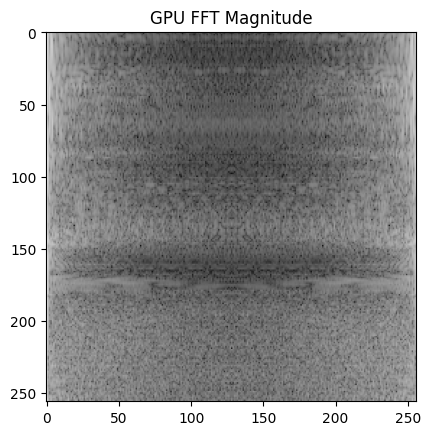

In [ ]:
from numba import cuda
import numpy as np
import cv2
from time import time
import matplotlib.pyplot as plt

# ---------------------------------
# GPU Kernel
# ---------------------------------
@cuda.jit
def row_fft_kernel(img, out_real, out_imag):

    row = cuda.grid(1)

    if row < img.shape[0]:

        N = img.shape[1]

        for u in range(N):

            real = 0.0
            imag = 0.0

            for k in range(N):

                angle = -2.0 * np.pi * u * k / N

                real += img[row, k] * np.cos(angle)
                imag += img[row, k] * np.sin(angle)

            out_real[row, u] = real
            out_imag[row, u] = imag


# ---------------------------------
# Load image
# ---------------------------------
img = cv2.imread('landscape.jpeg', 0)

img = cv2.resize(img, (256,256))

img = img.astype(np.float32)

# ---------------------------------
# Allocate GPU memory
# ---------------------------------
d_img = cuda.to_device(img)

out_real = cuda.device_array((256,256), dtype=np.float32)
out_imag = cuda.device_array((256,256), dtype=np.float32)

# ---------------------------------
# Launch kernel
# ---------------------------------
threads_per_block = 32
blocks_per_grid = (img.shape[0] + (threads_per_block - 1)) // threads_per_block

start = time()

row_fft_kernel[blocks_per_grid, threads_per_block](d_img, out_real, out_imag)

cuda.synchronize()

end = time()

print(f"Custom GPU FFT Time: {end-start:.6f} seconds")

# ---------------------------------
# Copy result back
# ---------------------------------
real = out_real.copy_to_host()
imag = out_imag.copy_to_host()

magnitude = np.sqrt(real**2 + imag**2)

plt.imshow(np.log(magnitude + 1), cmap='gray')
plt.title("GPU FFT Magnitude")
plt.show()